# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Após a coleta e o pré-processamento dos dados, inicia-se a Análise Exploratória, etapa em que o conjunto de dados é investigado, compreendido e resumido antes da aplicação de modelos ou da obtenção de conclusões definitivas

In [1]:
import pandas as pd                     # Biblioteca para manipulação e análise de dados
import matplotlib.pyplot as plt         # Biblioteca para criação de gráficos 2D
import seaborn as sns                   # Biblioteca para visualização estatística de dados
import os                               # Biblioteca para interação com o sistema de arquivos e diretórios
import numpy as np                      # Biblioteca para calculo para vetores e matrizes

In [2]:
import sys                              # 
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))  # Adiciona raiz

# Define constantes que armazenam os caminhos que serão utilizados neste notebook
from config_path import RAW_DATA_DIRECTORY_PATH, PROCESSED_DATA_DIRECTORY_PATH, REPORTS_DIRECTORY_PATH

In [3]:
# Caso a pasta 'reports' tenha sido excluida, o notebook cria ela

if not os.path.isdir(REPORTS_DIRECTORY_PATH):
    os.mkdir(REPORTS_DIRECTORY_PATH)

## Análise Exploratória

In [4]:
# 

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Carregar dados

In [5]:
df_municipios = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/educacao_basica_sexo_raca_cor.csv")
df_total_matriculas = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/quantidade_total_matriculas_alfabetizacao_dividida_mun.csv")
df_indice_gini = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/indice_de_gini_uf.csv")
df_uf = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_uf.csv")

In [6]:
# Selecionar apenas as colunas relevantes de cada DataFrame
df_alfabetizacao_1 = df_alfabetizacao[['id_municipio','nome_municipio','total_alfabetizados']]  # Total de alfabetizados por município
df_matriculas = df_educacao.groupby(['ano','id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município

# Merge sequencial dos DataFrames, combinando informações pelos IDs dos municípios
df = df_municipios.merge(df_alfabetizacao_1, on=['id_municipio'], how='inner')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','ano'], how='inner')  # Adiciona dados de matrículas
df.rename(columns={ 'id_municipio_nome_x' : 'id_municipio_nome'}, inplace=True)
df.drop('id_municipio_nome_y', axis=1, inplace=True)
df.drop('CD_MUN', axis=1, inplace=True)

# -------------------------------
# Criar colunas normalizadas (antes de qualquer análise)
# -------------------------------
# Evitar divisão por zero caso populacao_total tenha zeros
df['pib_per_capita'] = df['pib'] / df['populacao_total']
df['va_per_capita'] = df['valor_adicionado_precos_correntes_total'] / df['populacao_total']
df['taxa_alfabetizacao'] = df['total_alfabetizados'] / df['populacao_total']
df['taxa_matricula'] = df['quantidade_matricula'] / df['populacao_total']
df['densidade_populacional'] = df['populacao_total'] / df['AR_MUN_2024']
df['participacao_impostos'] = df['impostos_liquidos'] / df['pib']

# Conferir se as colunas foram criadas corretamente
print(df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula']].head())
del df_alfabetizacao_1

   pib_per_capita  va_per_capita  taxa_alfabetizacao  taxa_matricula
0    20251.418650   19268.823579            0.654188        0.263403
1    20749.572503   19675.487346            0.660397        0.254617
2    21538.395131   20318.772392            0.666811        0.245263
3    21607.103944   20327.914578            0.673262        0.236173
4    25089.845125   23545.098557            0.679690        0.241508


In [7]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,7067.127,Alta Floresta D'Oeste (RO),15448,6220,20251.418650,19268.823579,0.654188,0.263403,3.341386,0.048518
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5956,20749.572503,19675.487346,0.660397,0.254617,3.309973,0.051764
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5682,21538.395131,20318.772392,0.666811,0.245263,3.278136,0.056626
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5419,21607.103944,20327.914578,0.673262,0.236173,3.246722,0.059202
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5489,25089.845125,23545.098557,0.679690,0.241508,3.216017,0.061569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,5760.783,Brasília (DF),2219866,685168,81495.429074,71411.221068,0.768060,0.237064,501.706799,0.123740
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,5760.783,Brasília (DF),2219866,680622,83492.831767,73557.691986,0.757360,0.232210,508.794898,0.118994
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,5760.783,Brasília (DF),2219866,679257,85661.393759,76015.964283,0.746248,0.228344,516.371299,0.112599
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,5760.783,Brasília (DF),2219866,678504,90742.750230,80565.675754,0.736209,0.225023,523.412876,0.112153


In [8]:
print("## 1. Visão Geral e Estatísticas Descritivas")
# Informações básicas do DataFrame
print("\n--- Informações do DataFrame ---")
df_uf.info()
df_alfabetizacao.info()
df_educacao.info()
df_municipios.info()

# Estatísticas descritivas para colunas numéricas
print("\n--- Estatísticas Descritivas ---")
print(df_uf.describe())

## 1. Visão Geral e Estatísticas Descritivas

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 15 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ano                                                               135 non-null    int64  
 1   id_uf                                                             135 non-null    int64  
 2   id_uf_sigla                                                       135 non-null    object 
 3   id_uf_nome                                                        135 non-null    object 
 4   sigla_uf                                                          135 non-null    object 
 5   sigla_uf_nome                                                     135 non-null    object 
 6   pib                                                

### Filtrar Lavras

Realizaremos uma análise exploratória a partir de Lavras no ano de 2020. Nele iremos realizar algumas comparações e aprender alguns detalhes sobre esse múnicipio, e como ele se compara em relação a outros. Como tambem informações estaduais.

In [9]:
lavras_pop_2020 = df_municipios.loc[df_municipios['id_municipio_nome'] == 'Lavras']
lavras_pop_2020 = lavras_pop_2020.loc[lavras_pop_2020['ano'] == 2020]
lavras_alf = df_alfabetizacao[df_alfabetizacao['nome_municipio'] == 'Lavras (MG)'] # alfabetização é do ano de 2022
lavras_edu = df_educacao[df_educacao['id_municipio_nome'] == 'Lavras']

### Indicadores de Lavras - Ano 2020

In [10]:
quant_pop_lavras_2020 = lavras_pop_2020['populacao_total'].values[0]
total_alfabetizados = lavras_alf['total_alfabetizados'].values[0]
total_nao_alfabetizados = lavras_alf['total_nao_alfabetizados'].values[0]
tamanho_lavras = lavras_pop_2020['AR_MUN_2024'].values[0]
total_matriculas = lavras_edu['quantidade_matricula'].sum()
pib = lavras_pop_2020['pib'].values[0]
va_total = lavras_pop_2020['valor_adicionado_precos_correntes_total'].values[0]
taxa_alfabetizacao = total_alfabetizados / quant_pop_lavras_2020

print(f"Dados do Múnicipio de Lavras (Minas Gerais) em 2020:")
print(f"Populacao Lavras: {quant_pop_lavras_2020} habitantes")
print(f"Densidade Populacional: {(quant_pop_lavras_2020 / tamanho_lavras):.5f} habs/km2")
print(f"Total Não Alfabetizados {total_nao_alfabetizados}")
print(f"Total Alfabetizados: {total_alfabetizados}")
print(f"Total Alfabetizados e Nao Alfabetizados: {total_alfabetizados + total_nao_alfabetizados}")
print(f"Taxa Alfabetização: {(taxa_alfabetizacao * 100):.2f}%")
print(f"Total Matriculas: {total_matriculas}")
print(f"Pib total: {pib / 1_000_000} milhoes")
print(f"Valor bruto total: {va_total / 1_000_000} milhoes")

Dados do Múnicipio de Lavras (Minas Gerais) em 2020:
Populacao Lavras: 104783 habitantes
Densidade Populacional: 185.54071 habs/km2
Total Não Alfabetizados 2214
Total Alfabetizados: 84909
Total Alfabetizados e Nao Alfabetizados: 87123
Taxa Alfabetização: 81.03%
Total Matriculas: 111466
Pib total: 2677.947 milhoes
Valor bruto total: 2365.365 milhoes


### Indicadores do estado de MG - Ano 2020

In [11]:
# Vamos utilizar o estado de MG no ano de 2020 como indicador mais recente
df_mg = df_municipios.loc[df_municipios['NM_UF_SIGLA'] == 'MG']
df_mg = df_mg.loc[df_mg['ano'] == 2020]


In [12]:
# Calcular a quantidade total de habitantes em MG no ano de 2020
pop_mg = df_mg['populacao_total'].sum()
tamanho_km2_mg = df_mg['AR_MUN_2024'].sum()
densidade_populacional_mg = pop_mg / tamanho_km2_mg
proporcao_pop = (quant_pop_lavras_2020 / pop_mg) * 100

# Taxa de alfabetização de todos os municípios de MG
df_mg_alf = df_alfabetizacao.merge(df_mg, on=['id_municipio'], how="inner")
df_mg_alf.drop(columns={ 'nome_municipio' }, inplace=True)
df_mg_alf['taxa_alfabetizacao'] = (df_mg_alf['total_alfabetizados'] / df_mg_alf['populacao_total']) * 100

# Total Nao Alfabetizados e Alfabetizados MG
alfabetizados_mg = df_mg_alf['total_alfabetizados'].sum()
nao_alfabetizados_mg = df_mg_alf['total_nao_alfabetizados'].sum()

# Ranking de Lavras em MG
rank_alf_mg = df_mg_alf['taxa_alfabetizacao'].rank(ascending=False)[df_mg_alf['id_municipio'] == 3138203]
rank_pop_mg = df_mg['populacao_total'].rank(ascending=False)[df_mg['id_municipio'] == 3138203]

In [13]:
rank_pop_mg

13404    33.0
Name: populacao_total, dtype: float64

In [14]:
print("Informações em Minas Gerais:")
print(f"Quantidade total de habitantes: {pop_mg} habitantes")
print(f"Total Alfabetizados MG: {alfabetizados_mg}")
print(f"Total Não Alfabetizados MG: {nao_alfabetizados_mg}")
print(f"Total Alfabetizados e Nao Alfabetizados MG: {nao_alfabetizados_mg + alfabetizados_mg}")
print(f"Taxa de Alfabetização Geral MG: {((alfabetizados_mg / (nao_alfabetizados_mg + alfabetizados_mg)) * 100):.2f}%")
print(f"Ranking de alfabetização em MG: {rank_alf_mg.values[0]}")
print(f"Ranking populacional de MG: {rank_pop_mg.values[0]}")

Informações em Minas Gerais:
Quantidade total de habitantes: 21292666 habitantes
Total Alfabetizados MG: 15847064
Total Não Alfabetizados MG: 985006
Total Alfabetizados e Nao Alfabetizados MG: 16832070
Taxa de Alfabetização Geral MG: 94.15%
Ranking de alfabetização em MG: 98.0
Ranking populacional de MG: 33.0


### Ranking Brasil

In [15]:
df_municipios_2020 = df_municipios.loc[df_municipios["ano"] == 2020, :]
df_brasil = df_municipios_2020.merge(df_alfabetizacao, on=['id_municipio', 'id_municipio'])
df_brasil['taxa_alfabetizacao'] = df_brasil['total_alfabetizados'] / df_brasil['populacao_total'] * 100

rank_alf_brasil = df_brasil['taxa_alfabetizacao'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop_2020['id_municipio'].values[0]].values[0]
rank_pop_brasil = df_brasil['populacao_total'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop_2020['id_municipio'].values[0]].values[0]

print(f"Rank de alfabetização do Brasil: {rank_alf_brasil}")
print(f"Rank populacional do Brasil: {rank_pop_brasil}")

del df_municipios_2020

Rank de alfabetização do Brasil: 749.0
Rank populacional do Brasil: 309.0


### Indicadores Lavras

In [16]:
indicadores_lavras = pd.DataFrame({
    'id_municipio': [lavras_pop_2020['id_municipio'].values[0]],
    'municipio': ['Lavras'],
    'impostos_liquidos': [lavras_pop_2020['impostos_liquidos'].values[0]],
    'populacao_total': [lavras_pop_2020['populacao_total'].values[0]],
    'total_alfabetizados': [total_alfabetizados],
    'taxa_alfabetizacao': [taxa_alfabetizacao],
    'total_matriculas': [total_matriculas],
    'pib': [pib],
    'va_total_milhoes': [va_total],
    'populacao_estado_mg': [pop_mg],
    'proporcao_pop_estado_mg': [proporcao_pop],
    'rank_alfabetizacao_mg': [rank_alf_mg.values[0]],
    'rank_populacao_mg': [rank_pop_mg.values[0]],
    'rank_alfabetizacao_brasil': [rank_alf_brasil],
    'rank_populacao_brasil': [rank_pop_brasil],
    'taxa_matricula': [total_matriculas / lavras_pop_2020['populacao_total'].values[0]],
    'pib_per_capita': [pib / lavras_pop_2020['populacao_total'].values[0]],
    'va_per_capita': [va_total / lavras_pop_2020['populacao_total'].values[0]],
    'participacao_impostos': [lavras_pop_2020['impostos_liquidos'].values[0] / pib],
})

indicadores_lavras.to_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/indicadores_lavras_completo.csv", index=False)
print(indicadores_lavras)

   id_municipio municipio  impostos_liquidos  populacao_total  \
0       3138203    Lavras          312582000           104783   

   total_alfabetizados  taxa_alfabetizacao  total_matriculas         pib  \
0                84909            0.810332            111466  2677947000   

   va_total_milhoes  populacao_estado_mg  proporcao_pop_estado_mg  \
0        2365365000             21292666                 0.492108   

   rank_alfabetizacao_mg  rank_populacao_mg  rank_alfabetizacao_brasil  \
0                   98.0               33.0                      749.0   

   rank_populacao_brasil  taxa_matricula  pib_per_capita  va_per_capita  \
0                  309.0        1.063779    25557.075098   22573.938521   

   participacao_impostos  
0               0.116724  


## Gráficos Comparativos

#### 1. Taxa de alfabetização de Lavras vs MG - 2020

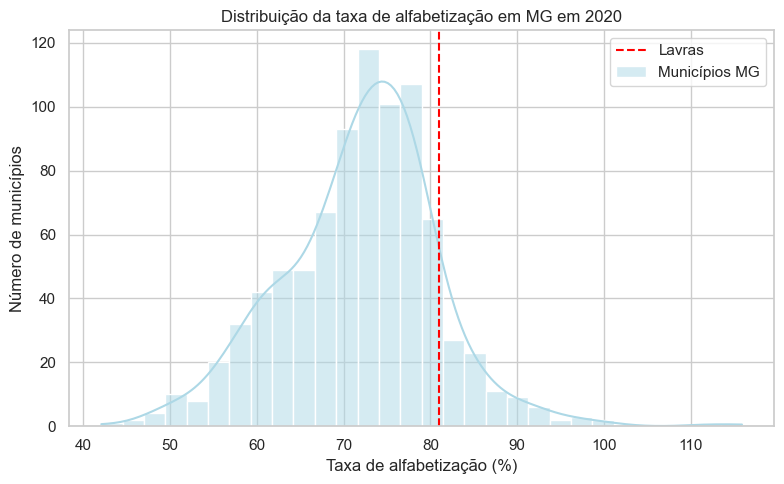

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(
    df_mg_alf['taxa_alfabetizacao'],
    bins=30,
    kde=True,
    color='lightblue',
    label='Municípios MG'
)
plt.axvline(taxa_alfabetizacao * 100, color='red', linestyle='--', label='Lavras')
plt.title('Distribuição da taxa de alfabetização em MG em 2020')
plt.xlabel('Taxa de alfabetização (%)')
plt.ylabel('Número de municípios')
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '01_taxa_alfabetizacao_lavras_vs_mg.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()  # fecha a figura para não mostrar

#### 2. População de Lavras vs top 10 municípios MG - 2020

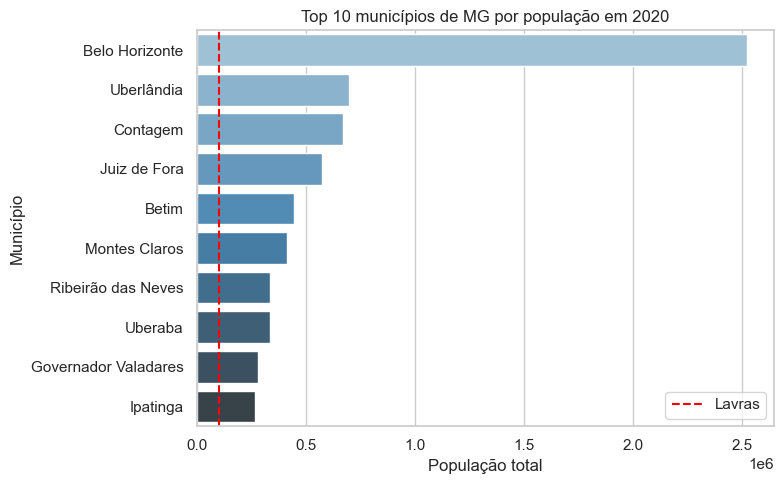

In [18]:
top10_pop_mg = df_mg.sort_values('populacao_total', ascending=False).head(10)

# Criar lista de cores para cada barra
cores = sns.color_palette("Blues_d", n_colors=len(top10_pop_mg))

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10_pop_mg,
    x='populacao_total',
    y='id_municipio_nome',
    palette=cores,
    hue='id_municipio_nome'
)
plt.axvline(quant_pop_lavras_2020, color='red', linestyle='--', label='Lavras')
plt.title('Top 10 municípios de MG por população em 2020')
plt.xlabel('População total')
plt.ylabel('Município')
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '02_pop_lavras_vs_top10_mun_mg.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()

#### 3. PIB vs Valor Adicionado de Lavras

In [19]:
df[df['id_municipio_nome'] == "Lavras"]

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos
13400,3138203,2016,100605,Lavras,2273631000,251732000,2021899000,89592000,370481000,1169498000,...,564.744,Lavras (MG),84909,22927,22599.582526,20097.400726,0.843984,0.227891,178.142663,0.110718
13401,3138203,2017,101651,Lavras,2486306000,292773000,2193533000,73842000,426352000,1273383000,...,564.744,Lavras (MG),84909,23171,24459.237981,21579.059724,0.835299,0.227947,179.994830,0.117754
13402,3138203,2018,102728,Lavras,2621298000,310017000,2311281000,65954000,434926000,1376003000,...,564.744,Lavras (MG),84909,22340,25516.879527,22499.036290,0.826542,0.217467,181.901888,0.118269
13403,3138203,2019,103773,Lavras,2764787000,331928000,2432859000,69625000,456482000,1462749000,...,564.744,Lavras (MG),84909,21611,26642.643077,23444.046139,0.818219,0.208253,183.752284,0.120056
13404,3138203,2020,104783,Lavras,2677947000,312582000,2365365000,102313000,410669000,1389748000,...,564.744,Lavras (MG),84909,21417,25557.075098,22573.938521,0.810332,0.204394,185.540705,0.116724


In [20]:
anos = df[df['id_municipio_nome'] == "Lavras"].ano.tolist()
pibs = df[df['id_municipio_nome'] == "Lavras"].pib.tolist()
vas_totais = df[df['id_municipio_nome'] == "Lavras"].valor_adicionado_precos_correntes_total.tolist()


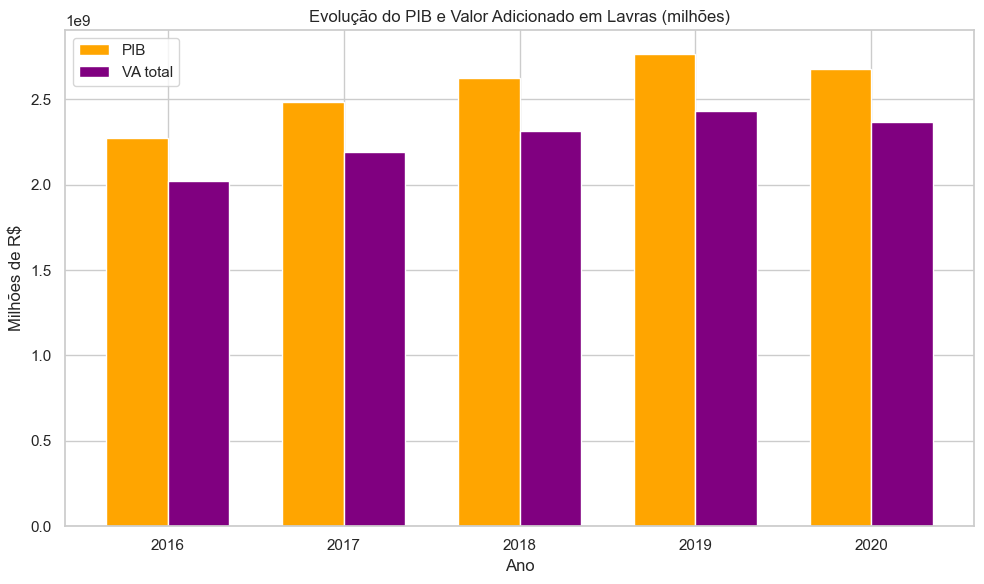

In [21]:
x = np.arange(len(anos))  # Localização das etiquetas
largura = 0.35            # Largura das barras

plt.figure(figsize=(10, 6))

# Criando as barras lado a lado
plt.bar(x - largura/2, pibs, largura, label='PIB', color='orange')
plt.bar(x + largura/2, vas_totais, largura, label='VA total', color='purple')

# Estilização
plt.title('Evolução do PIB e Valor Adicionado em Lavras (milhões)')
plt.xlabel('Ano')
plt.ylabel('Milhões de R$')
plt.xticks(x, anos) # Define os anos no eixo X
plt.legend()

plt.tight_layout()

# Salvando o arquivo
plt.savefig(os.path.join(REPORTS_DIRECTORY_PATH, '03_evolucao_pib_vs_va_lavras.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

### 4. Grafico do Indice de Gini

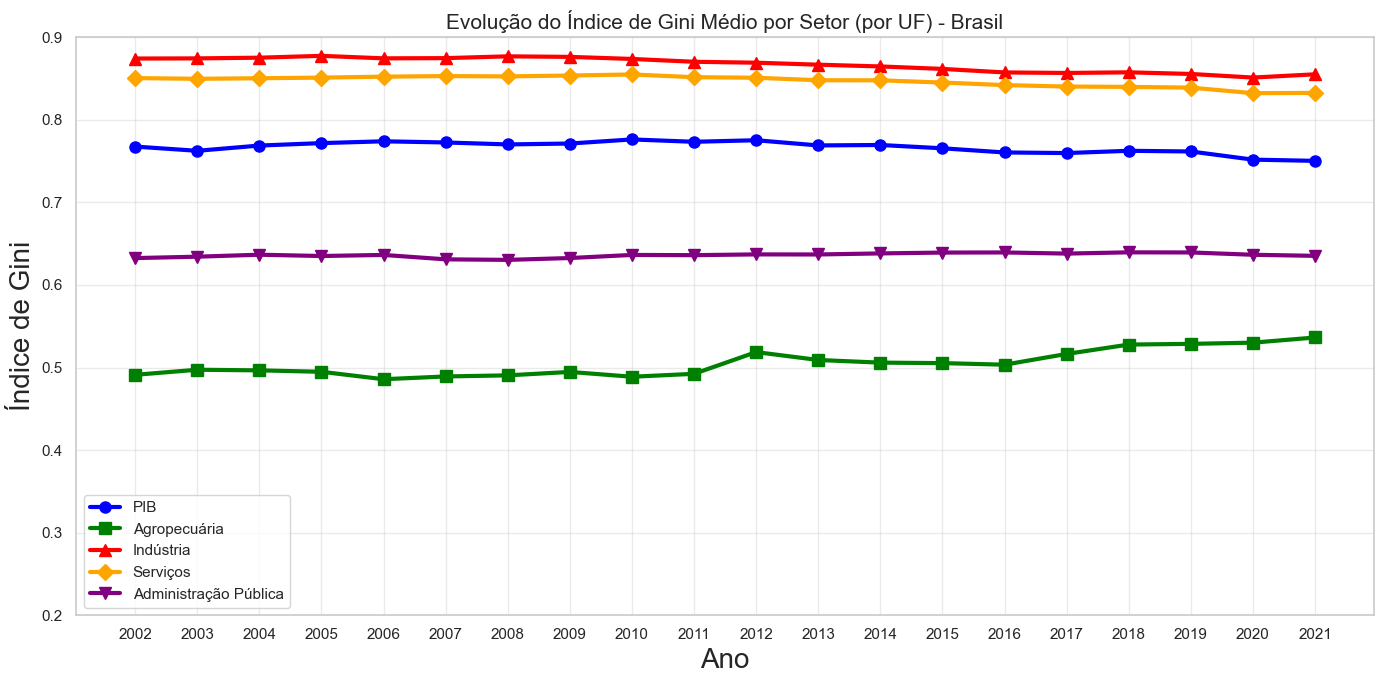

In [22]:
df_aux = df_indice_gini.groupby(['ano']).mean()

anos = df_aux.index.array


plt.figure(figsize=(14, 7))
plt.plot(anos, df_aux['gini_pib'], marker='o', linewidth=3, markersize=8, label='PIB', color='blue')
plt.plot(anos, df_aux['gini_va_agro'], marker='s', linewidth=3, markersize=8, label='Agropecuária', color='green')
plt.plot(anos, df_aux['gini_va_industria'], marker='^', linewidth=3, markersize=8, label='Indústria', color='red')
plt.plot(anos, df_aux['gini_va_servicos'], marker='D', linewidth=3, markersize=8, label='Serviços', color='orange')
plt.plot(anos, df_aux['gini_va_adespss'], marker='v', linewidth=3, markersize=8, label='Administração Pública', color='purple')

plt.title('Evolução do Índice de Gini Médio por Setor (por UF) - Brasil', fontsize=15)
plt.xlabel('Ano', fontsize=20)
plt.ylabel('Índice de Gini', fontsize=20)
plt.legend()
plt.grid(True, alpha=0.4)
plt.ylim(0.2, 0.9)
plt.xticks(anos.astype(int)) 
plt.tight_layout()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '04_grafico_evo_indice_gini_medio_por_setor.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()

del anos

### 5. Correlação de Indicadores Socioeconomicos entre todos os Municipios do Brasil entre 2016 a 2020

In [23]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,7067.127,Alta Floresta D'Oeste (RO),15448,6220,20251.418650,19268.823579,0.654188,0.263403,3.341386,0.048518
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5956,20749.572503,19675.487346,0.660397,0.254617,3.309973,0.051764
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5682,21538.395131,20318.772392,0.666811,0.245263,3.278136,0.056626
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5419,21607.103944,20327.914578,0.673262,0.236173,3.246722,0.059202
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5489,25089.845125,23545.098557,0.679690,0.241508,3.216017,0.061569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,5760.783,Brasília (DF),2219866,685168,81495.429074,71411.221068,0.768060,0.237064,501.706799,0.123740
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,5760.783,Brasília (DF),2219866,680622,83492.831767,73557.691986,0.757360,0.232210,508.794898,0.118994
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,5760.783,Brasília (DF),2219866,679257,85661.393759,76015.964283,0.746248,0.228344,516.371299,0.112599
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,5760.783,Brasília (DF),2219866,678504,90742.750230,80565.675754,0.736209,0.225023,523.412876,0.112153


Matriz de correlação:
                         pib_per_capita  va_per_capita  taxa_alfabetizacao  \
pib_per_capita                1.000000       0.994007            0.399123   
va_per_capita                 0.994007       1.000000            0.390613   
taxa_alfabetizacao            0.399123       0.390613            1.000000   
taxa_matricula               -0.098042      -0.098840           -0.144997   
densidade_populacional        0.076710       0.058360            0.077601   
participacao_impostos         0.353045       0.281800            0.357416   

                        taxa_matricula  densidade_populacional  \
pib_per_capita               -0.098042                0.076710   
va_per_capita                -0.098840                0.058360   
taxa_alfabetizacao           -0.144997                0.077601   
taxa_matricula                1.000000               -0.036093   
densidade_populacional       -0.036093                1.000000   
participacao_impostos        -0.095283   

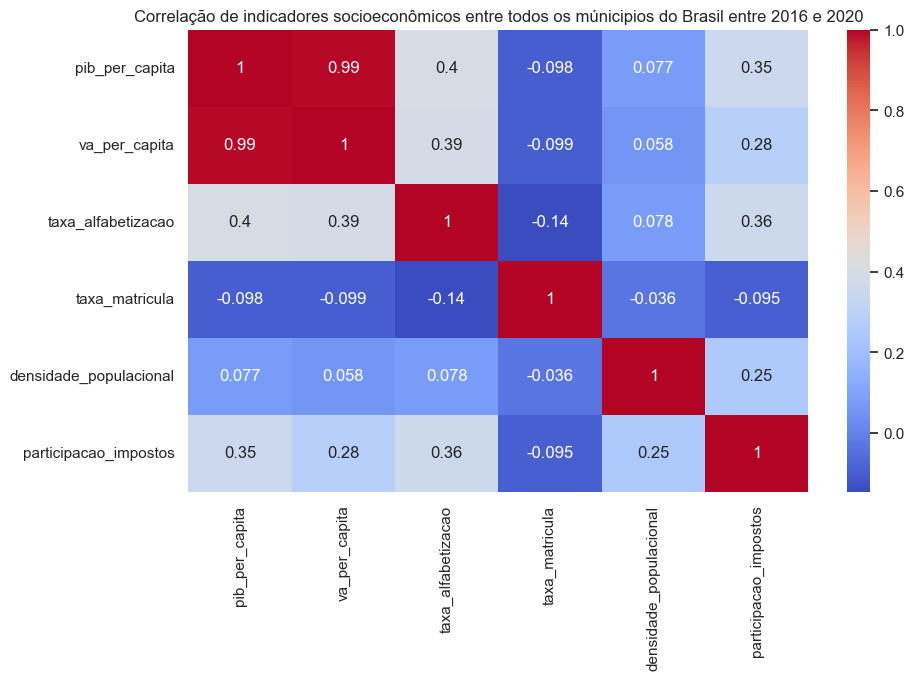

In [24]:
# Calcular a matriz de correlação entre os indicadores selecionados
# Por padrao, o método 'corr' aplica o método Pearson para achar a correlação
corr_matrix_mun = df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula', 'densidade_populacional', 'participacao_impostos']].corr()
print("Matriz de correlação:\n", corr_matrix_mun)  # Exibir a matriz no console

# Criar um heatmap da matriz de correlação usando Seaborn
sns.heatmap(corr_matrix_mun, annot=True, cmap='coolwarm')  # Heatmap com valores anotados e cores 'coolwarm'
plt.title('Correlação de indicadores socioeconômicos entre todos os múnicipios do Brasil entre 2016 e 2020')  # Título do gráfico

# Salvar a figura em alta resolução no diretório especificado
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '05_matriz_correlacao_mun_brasil_2016_a_2020.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória

### 7. Correlação de Indicadores Socioeconomicos entre Municipios de Minas Gerais entre 2016 a 2020

Matriz de correlação:
                         pib_per_capita  va_per_capita  taxa_alfabetizacao  \
pib_per_capita                1.000000       0.993743            0.359622   
va_per_capita                 0.993743       1.000000            0.342236   
taxa_alfabetizacao            0.359622       0.342236            1.000000   
taxa_matricula                0.063344       0.058414           -0.038739   
densidade_populacional        0.063889       0.052374            0.081885   
participacao_impostos         0.330493       0.267756            0.381667   

                        taxa_matricula  densidade_populacional  \
pib_per_capita                0.063344                0.063889   
va_per_capita                 0.058414                0.052374   
taxa_alfabetizacao           -0.038739                0.081885   
taxa_matricula                1.000000               -0.030740   
densidade_populacional       -0.030740                1.000000   
participacao_impostos        -0.021057   

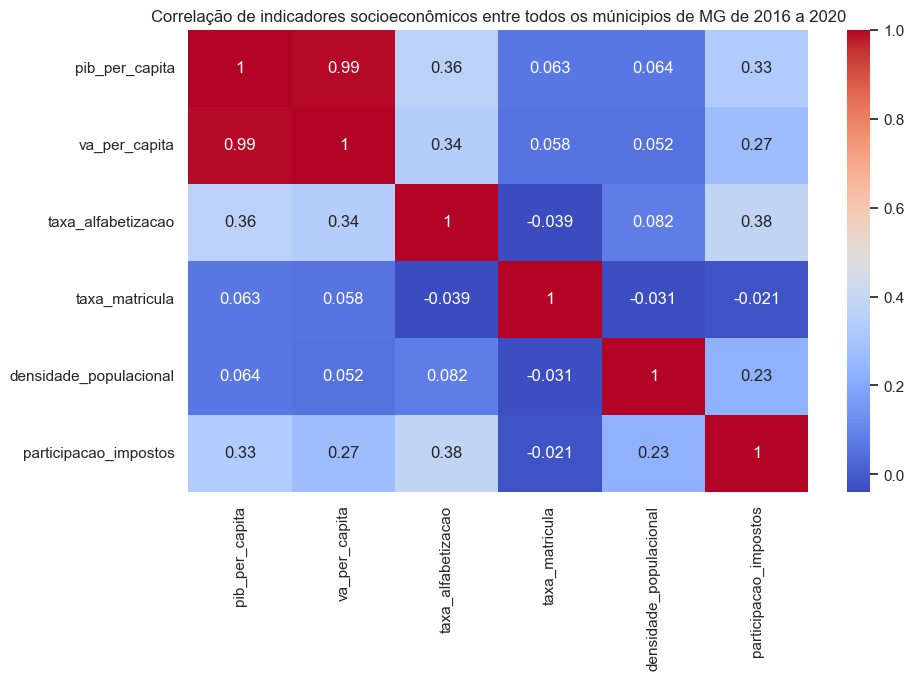

In [25]:
# Calcular a matriz de correlação entre os indicadores selecionados
mun_mg_2016_2020 = df[df['NM_UF_SIGLA'] == "MG"]
corr_matrix_mg = mun_mg_2016_2020[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula', 'densidade_populacional', 'participacao_impostos']].corr()
print("Matriz de correlação:\n", corr_matrix_mg)  # Exibir a matriz no console

# Criar um heatmap da matriz de correlação usando Seaborn
sns.heatmap(corr_matrix_mg, annot=True, cmap='coolwarm')  # Heatmap com valores anotados e cores 'coolwarm'
plt.title('Correlação de indicadores socioeconômicos entre todos os múnicipios de MG de 2016 a 2020')  # Título do gráfico

# Salvar a figura em alta resolução no diretório especificado
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '06_matriz_correlacao_todos_os_municipios_mg_2016_a_2020.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória

### 9. Scatter Plot População vs PIB a nível MG de 2016 a 2020

In [26]:
df

,id_municipio,ano,populacao_total,id_municipio_nome,pib,impostos_liquidos,valor_adicionado_precos_correntes_total,valor_adicionado_correntes_agropecuaria,valor_adicionado_correntes_industria,valor_adicionado_correntes_servicos,...,AR_MUN_2024,nome_municipio,total_alfabetizados,quantidade_matricula,pib_per_capita,va_per_capita,taxa_alfabetizacao,taxa_matricula,densidade_populacional,participacao_impostos
0,1100015,2016,23614,Alta Floresta D'Oeste,478217000,23202000,455014000,166143000,31598000,114541000,...,7067.127,Alta Floresta D'Oeste (RO),15448,6220,20251.418650,19268.823579,0.654188,0.263403,3.341386,0.048518
1,1100015,2017,23392,Alta Floresta D'Oeste,485374000,25125000,460249000,169623000,27342000,108357000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5956,20749.572503,19675.487346,0.660397,0.254617,3.309973,0.051764
2,1100015,2018,23167,Alta Floresta D'Oeste,498980000,28255000,470725000,165892000,26060000,123502000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5682,21538.395131,20318.772392,0.666811,0.245263,3.278136,0.056626
3,1100015,2019,22945,Alta Floresta D'Oeste,495775000,29351000,466424000,162668000,14468000,130314000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5419,21607.103944,20327.914578,0.673262,0.236173,3.246722,0.059202
4,1100015,2020,22728,Alta Floresta D'Oeste,570242000,35109000,535133000,203394000,20715000,150233000,...,7067.127,Alta Floresta D'Oeste (RO),15448,5489,25089.845125,23545.098557,0.679690,0.241508,3.216017,0.061569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,5300108,2016,2890224,Brasília,235540045000,29145619000,206394425000,820755000,9662357000,103859866000,...,5760.783,Brasília (DF),2219866,685168,81495.429074,71411.221068,0.768060,0.237064,501.706799,0.123740
27846,5300108,2017,2931057,Brasília,244722249000,29120462000,215601788000,828314000,8448768000,108322119000,...,5760.783,Brasília (DF),2219866,680622,83492.831767,73557.691986,0.757360,0.232210,508.794898,0.118994
27847,5300108,2018,2974703,Brasília,254817205000,28692287000,226124917000,1022691000,9541298000,113768087000,...,5760.783,Brasília (DF),2219866,679257,85661.393759,76015.964283,0.746248,0.228344,516.371299,0.112599
27848,5300108,2019,3015268,Brasília,273613711000,30686608000,242927104000,992394000,9453608000,125261853000,...,5760.783,Brasília (DF),2219866,678504,90742.750230,80565.675754,0.736209,0.225023,523.412876,0.112153


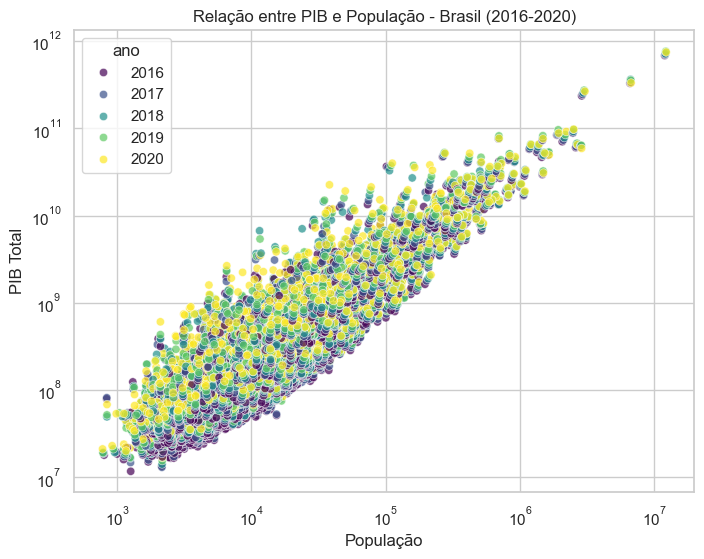

In [27]:
# Filtrar o nível desejado, por exemplo, MG
df_plot = df[df['NM_UF_SIGLA'] == 'MG']

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='populacao_total',
    y='pib',
    data=df,
    hue='ano',      # opcional, para ver evolução temporal
    palette='viridis',
    alpha=0.7
)

plt.xscale('log')  # opcional: melhor visualização
plt.yscale('log')  # opcional: melhor visualização
plt.xlabel('População')
plt.ylabel('PIB Total')


plt.title('Relação entre PIB e População - Brasil (2016-2020)')
# Salvar a figura em alta resolução no diretório especificado
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", '07_scatter_plot_pib_pop_brasil_2016_2020.png'), dpi=300, bbox_inches='tight')
plt.show()
